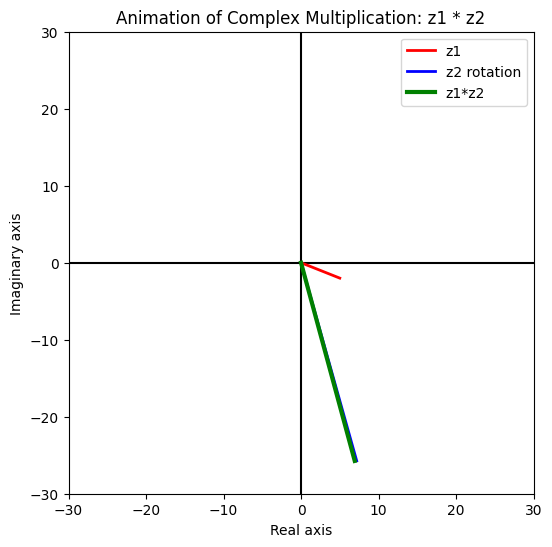

In [1]:
from matplotlib import rc
rc('animation', html='jshtml')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Complex numbers from Lecture 2
z1 = 5 - 2j
z2 = 3 - 4j
z_prod = z1 * z2

# Convert to components
x1, y1 = z1.real, z1.imag
x2, y2 = z2.real, z2.imag
xp, yp = z_prod.real, z_prod.imag

# Polar angles
theta1 = np.angle(z1)
theta2 = np.angle(z2)

# Setup figure
fig, ax = plt.subplots(figsize=(6,6))
ax.set_xlim(-30, 30)
ax.set_ylim(-30, 30)
ax.set_xlabel("Real axis")
ax.set_ylabel("Imaginary axis")
ax.set_title("Animation of Complex Multiplication: z1 * z2")

# Axes
ax.axhline(0, color='black')
ax.axvline(0, color='black')

# Elements to animate
vec1, = ax.plot([], [], 'r-', linewidth=2, label="z1")
vec2, = ax.plot([], [], 'b-', linewidth=2, label="z2 rotation")
vecp, = ax.plot([], [], 'g-', linewidth=3, label="z1*z2")

ax.legend()

def update(frame):
    t = frame / 100

    # z1 is static
    vec1.set_data([0, x1], [0, y1])

    # Animate rotation of z1 by angle t*theta2
    angle = theta1 + t * theta2
    length = np.abs(z1) * (1 + t * (np.abs(z2) - 1))  # scaling
    x_rot = length * np.cos(angle)
    y_rot = length * np.sin(angle)
    vec2.set_data([0, x_rot], [0, y_rot])

    # Final product vector appears gradually
    vecp.set_data([0, t * xp], [0, t * yp])

    return vec1, vec2, vecp

ani = FuncAnimation(fig, update, frames=100, interval=40, blit=True)
ani